In [77]:
import random
import numpy as np
import matplotlib.pyplot as plt
random_seed =1


In [207]:
def plot_iteration(data, medoids, x_medoid_assignment, iteration):
    plt.figure(figsize=(6,6))
    
    # Scatter plot of points by cluster
    for k in range(len(medoids)):
        cluster_points = data[np.array(x_medoid_assignment) == k]
        plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f"Cluster {k}")
    
    # Plot medoids
    plt.scatter(medoids[:,0], medoids[:,1], marker='*', s=200, color='black', label='Medoids')
    
    plt.title(f"K-Medoids Iteration {iteration}")
    plt.legend()
    plt.show()


In [208]:
  # for reproducibility    
def assign_medoids(data,medoids):
    x_medoid_assignment = []
    # assign the point 
    for point in data:
        distances = np.linalg.norm(point - medoids, axis=1) # compute distances
        closest_medoid = np.argmin(distances) #min distances 
        x_medoid_assignment.append(closest_medoid) # store assignment 
    return x_medoid_assignment

def get_points(data,x_medoid_assignment,k):
    points = []
    for i in range(len(data)):
        # position in medoids  :  3 
        if x_medoid_assignment[i] == k:
            points.append(data[i])
    return np.array(points) 

def compute(points, medoid):
     #compute distance of all points 
     distances = np.linalg.norm(points - medoid, axis= 1 ) 
     # sum distances to get cost for m 
     cost = np.sum(distances)
     return cost 
     

def compute_cost(medoids, data,x_medoid_assignment):
    cost_medoids = []
    for k in range(len(medoids)):
        # get x assigned to medoids 
        points= get_points(data,x_medoid_assignment,k)
        cost = compute(points, medoids[k])
        # check C(m) vs C(o)
        all_possible_costs = []
        for i in range(len(points)):
             #recompute the distance here 
             new_medoid = points[i]
             # compute new cost 
             O_cost = compute(points, new_medoid)
             # add to list of all cost for the medroid 
             all_possible_costs.append(O_cost)

        all_possible_costs= np.array(all_possible_costs)

        # find min cost and reassign medoids 
        min_idx = np.argmin(all_possible_costs)
        medoids[k] = points[min_idx]
        cost = all_possible_costs[min_idx]
        cost_medoids.append(cost)
        
        # reassign data points based on new medoids 
        x_medoid_assignment = assign_medoids(data,medoids)
             

    return medoids,x_medoid_assignment, np.array(cost_medoids)


def k_medoids(data, k ):
    # set seed 
    np.random.seed(random_seed)

    # pick 3 unique indices from the data set 
    random_indices = np.random.choice(data.shape[0], k , replace = False)

    # get the values from the indices data[i]
    medoids = data[random_indices]
    x_medoid_assignment= assign_medoids(data,medoids)
    
    m_cost_sum = np.inf
    iteration = 0 

    while True:
    # get updated variables 
        medoids,x_medoid_assignment,m_cost = compute_cost(medoids, data,x_medoid_assignment)
        new_cost_sum = np.sum(m_cost)

        plot_iteration(data, medoids, x_medoid_assignment, iteration)
        iteration += 1


        if new_cost_sum >= m_cost_sum:
            break
        m_cost_sum = new_cost_sum
        





    return new_cost_sum,medoids,x_medoid_assignment

    

    
    
    

Text(0, 0.5, 'Y')

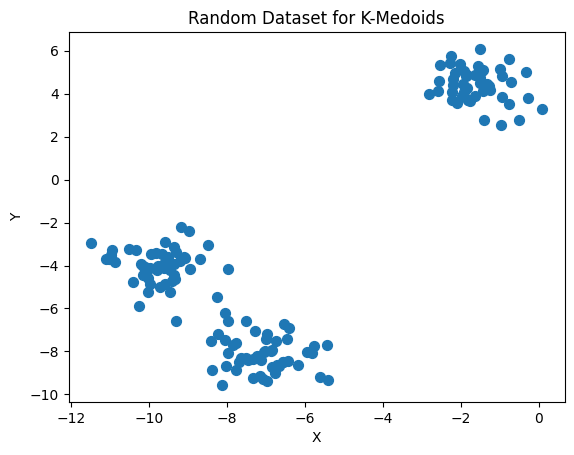

In [205]:

# Parameters
n_clusters = 3
points_per_cluster = 50
cluster_std = 0.8  # how spread out the clusters are
dim = 2  # 2D data

# Generate random cluster centers
np.random.seed(random_seed)  # for reproducibility
centers = np.random.uniform(-10, 10, (n_clusters, dim))

# Generate points around each center
data = []
for center in centers:
    cluster_points = center + cluster_std * np.random.randn(points_per_cluster, dim)
    data.append(cluster_points)

data = np.vstack(data)  # combine all points
# print(data)

# Plot the dataset
plt.scatter(data[:, 0], data[:, 1], s=50)
plt.title("Random Dataset for K-Medoids")
plt.xlabel("X")
plt.ylabel("Y")
# plt.show()

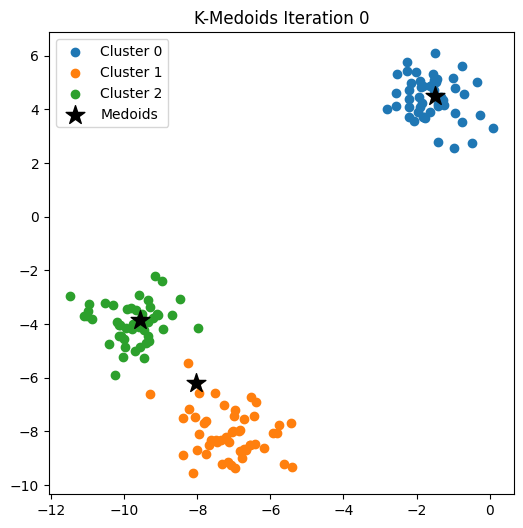

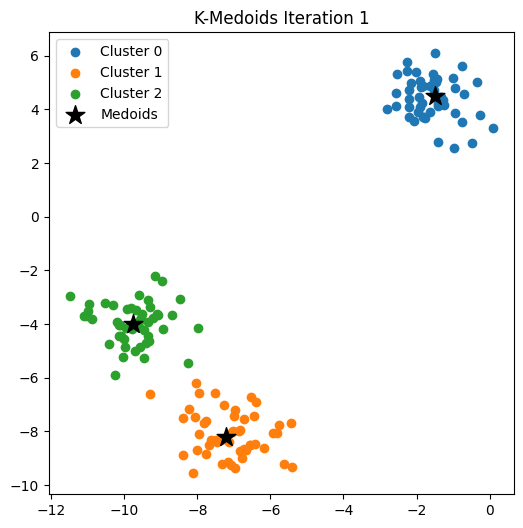

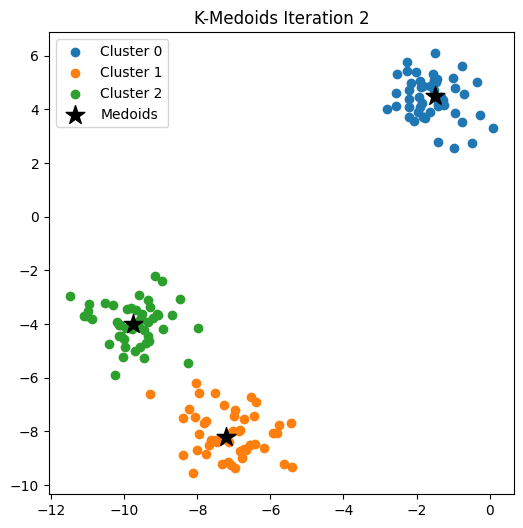

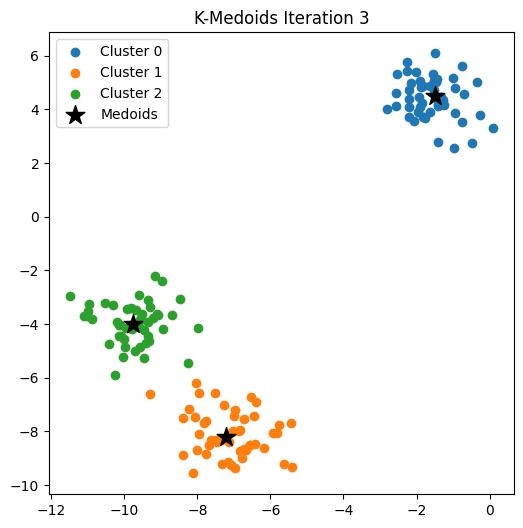

(np.float64(139.53959758613587), array([[-1.50092013,  4.50169679],
       [-7.21414538, -8.19868769],
       [-9.77318044, -4.01183871]]), [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), n

In [209]:
print(k_medoids(data=data, k = n_clusters))
